# Customer Churn Analysis

This notebook performs a full churn analysis including:
- Data loading
- Cleaning
- Exploratory analysis
- Visualizations
- Correlation analysis
- Business insights


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
sns.set(style='whitegrid')

## Load Dataset

In [3]:
df = pd.read_csv('telecom_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,tenure,PhoneService,InternetService,Contract,MonthlyCharges,TotalCharges,Churn
0,1,NaN,0,51,Yes,NaN,Month-to-month,84.27,4359.93,No
1,2,Female,0,3,No,Fiber,Month-to-month,113.84,294.06,Yes
2,3,Male,0,33,No,DSL,Month-to-month,118.23,3938.90,Yes
3,4,Male,1,68,Yes,DSL,Month-to-month,114.69,7802.21,Yes
4,5,Male,0,32,No,DSL,Two year,102.42,3238.60,Yes


## Dataset Overview

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customerID       5000 non-null   int64  
 1   gender           4772 non-null   str    
 2   SeniorCitizen    5000 non-null   int64  
 3   tenure           5000 non-null   int64  
 4   PhoneService     5000 non-null   str    
 5   InternetService  3770 non-null   str    
 6   Contract         5000 non-null   str    
 7   MonthlyCharges   4743 non-null   float64
 8   TotalCharges     5000 non-null   float64
 9   Churn            5000 non-null   str    
dtypes: float64(2), int64(3), str(5)
memory usage: 390.8 KB


In [5]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,tenure,PhoneService,InternetService,Contract,MonthlyCharges,TotalCharges,Churn
count,5000.000000,4772,5000.000000,5000.000000,5000,3770,5000,4743.000000,5000.000000,5000
unique,NaN,2,NaN,NaN,2,2,3,NaN,NaN,2
top,NaN,Male,NaN,NaN,Yes,Fiber,Month-to-month,NaN,NaN,No
freq,NaN,2389,NaN,NaN,2509,1952,2935,NaN,NaN,3617
mean,2500.500000,NaN,0.145000,35.798600,NaN,NaN,NaN,69.073654,2471.244730,NaN
std,1443.520003,NaN,0.352136,20.923699,NaN,NaN,NaN,28.496778,1871.976504,NaN
min,1.000000,NaN,0.000000,0.000000,NaN,NaN,NaN,20.010000,-88.160000,NaN
25%,1250.750000,NaN,0.000000,18.000000,NaN,NaN,NaN,44.355000,979.132500,NaN
50%,2500.500000,NaN,0.000000,36.000000,NaN,NaN,NaN,69.100000,2025.010000,NaN
75%,3750.250000,NaN,0.000000,54.000000,NaN,NaN,NaN,92.875000,3619.532500,NaN


## Handle Missing Values

In [6]:
df.isna().sum()

customerID            0
gender              228
SeniorCitizen         0
tenure                0
PhoneService          0
InternetService    1230
Contract              0
MonthlyCharges      257
TotalCharges          0
Churn                 0
dtype: int64

In [7]:
df['gender'] = df['gender'].fillna('Unknown')
df['InternetService'] = df['InternetService'].fillna('Unknown')
df['MonthlyCharges'] = df['MonthlyCharges'].fillna(df['MonthlyCharges'].median())

df.isna().sum()

customerID         0
gender             0
SeniorCitizen      0
tenure             0
PhoneService       0
InternetService    0
Contract           0
MonthlyCharges     0
TotalCharges       0
Churn              0
dtype: int64

## Feature Engineering

In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['ChurnFlag'] = df['Churn'].map({'Yes': 1, 'No': 0})
df[['MonthlyCharges', 'TotalCharges', 'tenure', 'ChurnFlag']].head()

,MonthlyCharges,TotalCharges,tenure,ChurnFlag
0,84.27,4359.93,51,0
1,113.84,294.06,3,1
2,118.23,3938.90,33,1
3,114.69,7802.21,68,1
4,102.42,3238.60,32,1


## Churn Distribution

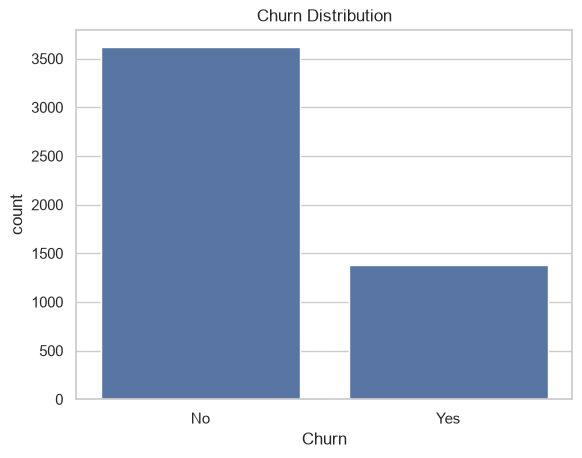

np.float64(0.2766)

In [9]:
sns.countplot(data=df, x='Churn')
plt.title('Churn Distribution')
plt.show()

df['ChurnFlag'].mean()

## Churn by Contract Type

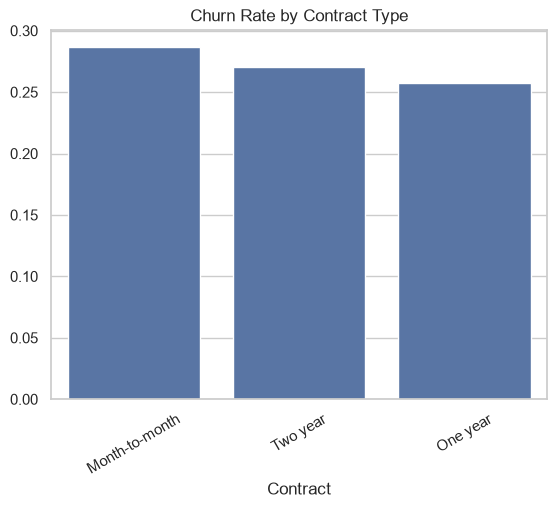

Contract
Month-to-month    0.286542
Two year          0.270375
One year          0.257740
Name: ChurnFlag, dtype: float64

In [10]:
contract_churn = df.groupby('Contract')['ChurnFlag'].mean().sort_values(ascending=False)
sns.barplot(x=contract_churn.index, y=contract_churn.values)
plt.title('Churn Rate by Contract Type')
plt.xticks(rotation=30)
plt.show()

contract_churn

## Churn by Tenure Bucket

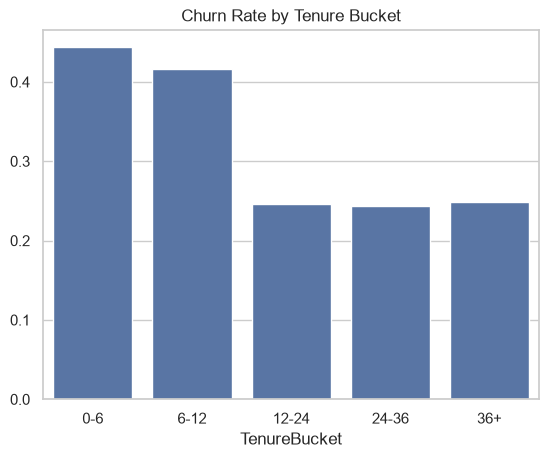

TenureBucket
0-6      0.443609
6-12     0.416021
12-24    0.246014
24-36    0.242979
36+      0.248475
Name: ChurnFlag, dtype: float64

In [11]:
bins = [0, 6, 12, 24, 36, 72]
labels = ['0-6', '6-12', '12-24', '24-36', '36+']
df['TenureBucket'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=False)

tenure_churn = df.groupby('TenureBucket')['ChurnFlag'].mean()
sns.barplot(x=tenure_churn.index, y=tenure_churn.values)
plt.title('Churn Rate by Tenure Bucket')
plt.show()

tenure_churn

## Monthly Charges vs Churn

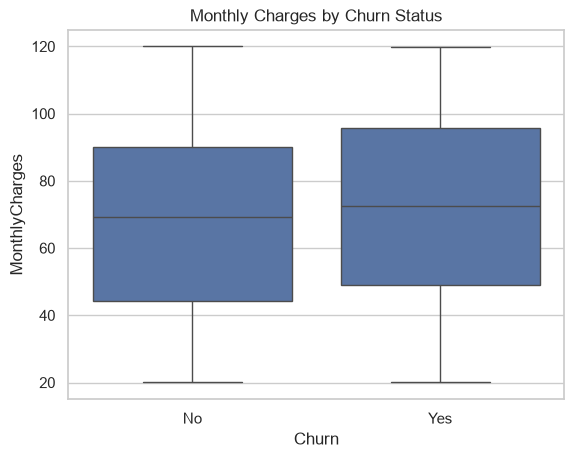

In [12]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges by Churn Status')
plt.show()

## Churn by Internet Service

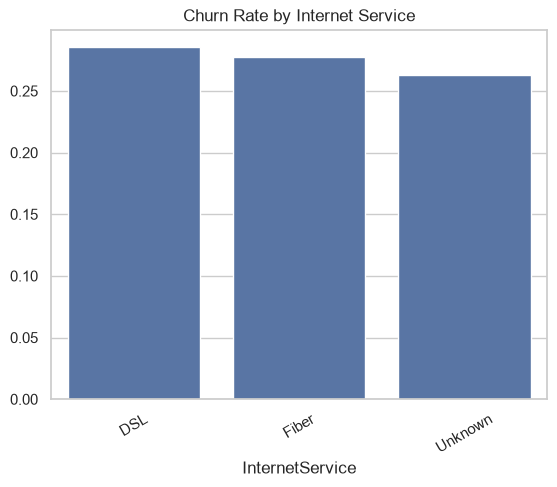

InternetService
DSL        0.285479
Fiber      0.277152
Unknown    0.262602
Name: ChurnFlag, dtype: float64

In [13]:
internet_churn = df.groupby('InternetService')['ChurnFlag'].mean().sort_values(ascending=False)
sns.barplot(x=internet_churn.index, y=internet_churn.values)
plt.title('Churn Rate by Internet Service')
plt.xticks(rotation=30)
plt.show()

internet_churn

## Correlation Heatmap

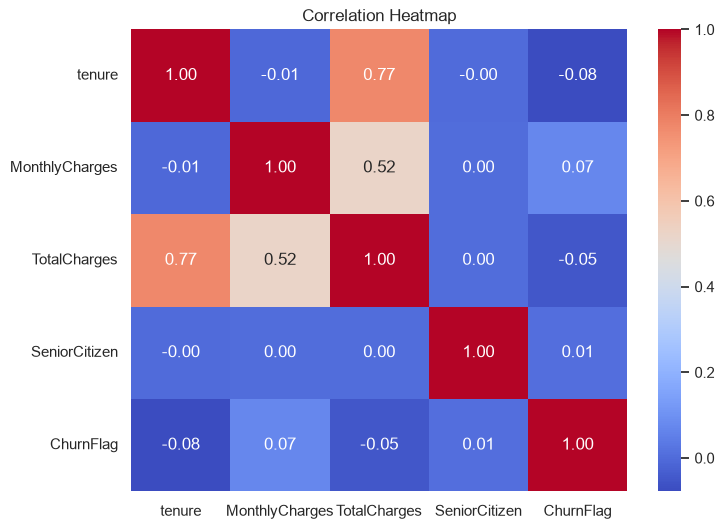

ChurnFlag         1.000000
MonthlyCharges    0.071308
SeniorCitizen     0.006940
TotalCharges     -0.050063
tenure           -0.078163
Name: ChurnFlag, dtype: float64

In [14]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'ChurnFlag']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

corr['ChurnFlag'].sort_values(ascending=False)

# Business Insights

1. Month-to-month customers churn the most.
2. High monthly charges correlate with churn.
3. Customers with low tenure churn significantly more.
4. Fiber customers show higher churn than DSL.
5. Tenure is strongly negatively correlated with churn.

These insights support targeted retention strategies such as:
- Discounts for high-charge month-to-month customers.
- Improved onboarding for new customers.
- Service quality improvements for Fiber customers.
